In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, BatchNormalization

import tensorflow as tf
tf.random.set_seed(42)
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')
from time import time
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot

In [190]:
df = pd.read_csv('indices_station_17150.csv', parse_dates=['date'], index_col='date')

In [191]:
df.head()

,station_id,SPI3,SPEI3,SPI6,SPEI6,SPI9,SPEI9,SPI12,SPEI12,SSFI3,SGI3
date,,,,,,,,,,,
1950-01-01,17150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-02-01,17150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-03-01,17150,-0.171185,-0.113648,NaN,NaN,NaN,NaN,NaN,NaN,0.277461,-2.479467
1950-04-01,17150,-1.114770,-1.276930,NaN,NaN,NaN,NaN,NaN,NaN,-0.457151,-2.479467
1950-05-01,17150,-0.209855,-0.285331,NaN,NaN,NaN,NaN,NaN,NaN,-0.597755,-2.479467


In [192]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 912 entries, 1950-01-01 to 2025-12-01
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   station_id  912 non-null    int64  
 1   SPI3        910 non-null    float64
 2   SPEI3       910 non-null    float64
 3   SPI6        907 non-null    float64
 4   SPEI6       907 non-null    float64
 5   SPI9        904 non-null    float64
 6   SPEI9       904 non-null    float64
 7   SPI12       901 non-null    float64
 8   SPEI12      901 non-null    float64
 9   SSFI3       910 non-null    float64
 10  SGI3        910 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 85.5 KB


In [193]:
df.head()

,station_id,SPI3,SPEI3,SPI6,SPEI6,SPI9,SPEI9,SPI12,SPEI12,SSFI3,SGI3
date,,,,,,,,,,,
1950-01-01,17150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-02-01,17150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-03-01,17150,-0.171185,-0.113648,NaN,NaN,NaN,NaN,NaN,NaN,0.277461,-2.479467
1950-04-01,17150,-1.114770,-1.276930,NaN,NaN,NaN,NaN,NaN,NaN,-0.457151,-2.479467
1950-05-01,17150,-0.209855,-0.285331,NaN,NaN,NaN,NaN,NaN,NaN,-0.597755,-2.479467


In [194]:
df = pd.DataFrame(df['SPEI3'].dropna())

In [195]:
df.head()

,SPEI3
date,
1950-03-01,-0.113648
1950-04-01,-1.276930
1950-05-01,-0.285331
1950-06-01,0.046618
1950-07-01,0.262051


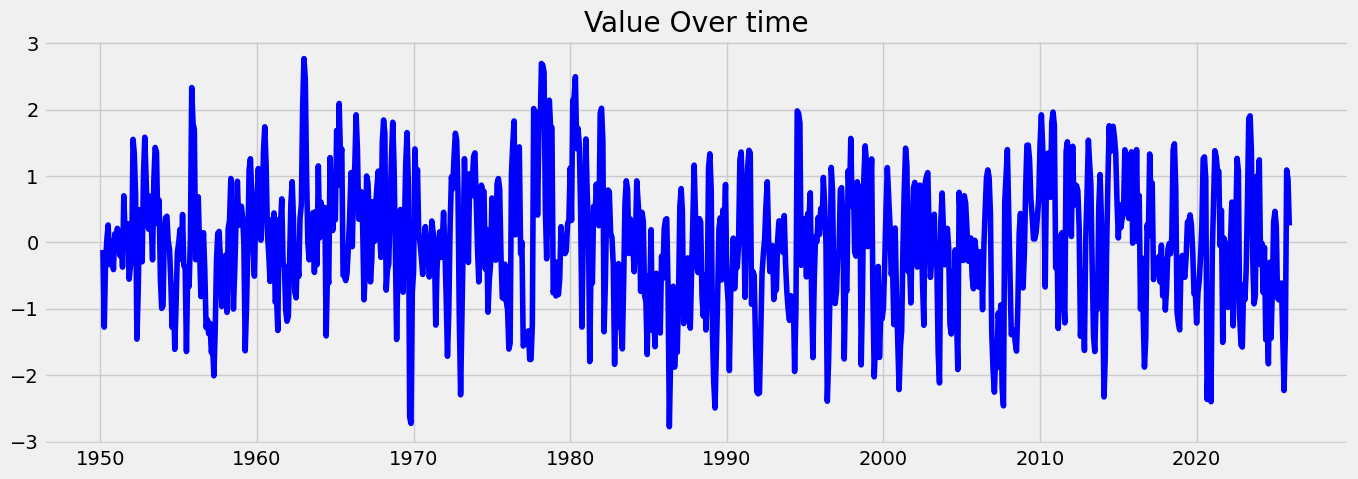

In [196]:
plt.figure(figsize=(15, 5))

plt.plot(df, color='blue')
plt.title('Value Over time')
plt.show()

**The time series data is not stationary, as it shows:**
- **A non-constant mean.**
- **Seasonality patterns over time.**
- **Changing variance.**

## Summary Statistics
### Checking Mean and Variance

In [197]:
rolling_mean = df.rolling(window=12).mean()
rolling_std = df.rolling(window=12).std()

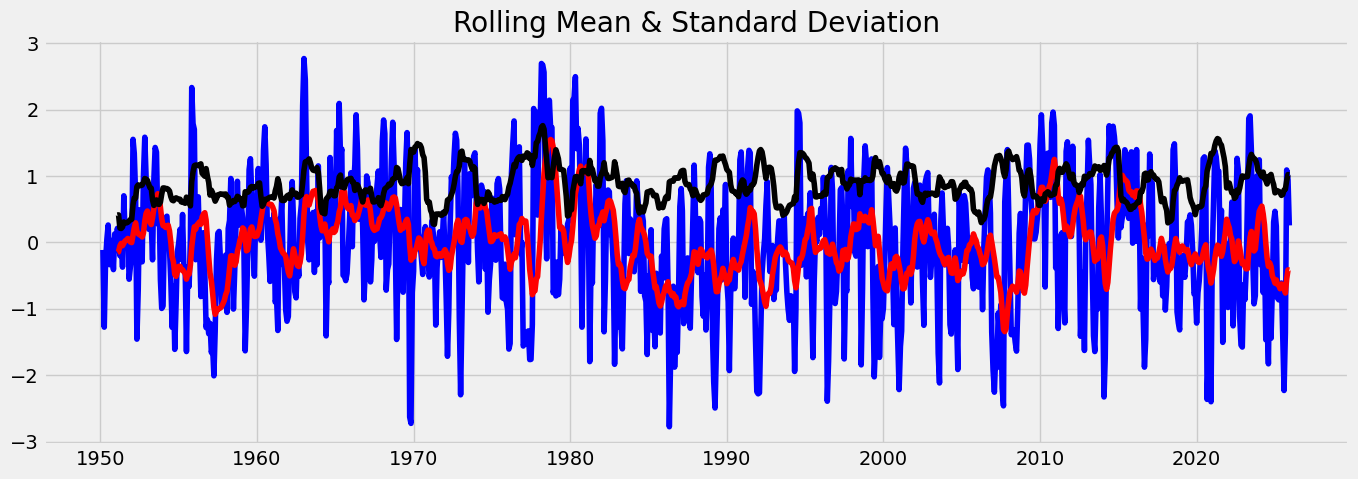

In [198]:
plt.figure(figsize=(15, 5))
plt.plot(df, color='blue', label='Original')
plt.plot(rolling_mean, color='red',label='Rolling Mean')
plt.plot(rolling_std, color='black',label='Rolling Std')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

`the variance not constant over time and mean not contant over time`

### **Observations from the Plot**
1. **Rolling Mean (Red Line):**
   - Represents the moving average (trend) over time.
   - The rolling mean is **not constant**; it follows an upward trend until the mid-2000s, after which it declines slightly.

2. **Rolling Standard Deviation (Black Line):**
   - Represents the rolling standard deviation of the data.
   - The standard deviation appears relatively stable over time, indicating **constant variance**.

3. **Original Data (Blue Line):**
   - Shows consistent seasonal fluctuations over time.
   - No evidence of irregular periodic behavior outside the seasonal pattern.

## ADF test


- **H0 is the data Non_statinonary**
- **H1 is the data stationary**
- **ADF test:A p-value less than 0.05 mean rejecting the null hypothesis and the data is stationary**

In [199]:
adf_test = sm.tsa.adfuller(df)
print('p-value: %f' % adf_test[1])

p-value: 0.000000


- **p-value > 0.05 mean the data Non_stationary**

## KPSS test


- **H0 is the data stationary**
- **H1 is the data Non-stationary**
- **KPSS test:A p-value greater than 0.05 mean failing to reject the null hypothesis and the data is stationary**

In [200]:
kpss_test = sm.tsa.kpss(df)
print('p-value: %f' % kpss_test[1])

p-value: 0.100000


C:\Users\ilchu\AppData\Local\Temp\ipykernel_20280\1525200867.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(df)


- **p-value < 0.05 mean the data Non_stationary**

`all that test said that the data is Non_stationary`

## Steps to Address Non-Stationarity

1. **Remove Trend (Constant Mean):**  
   - The data exhibits a **non-constant trend** (upward trend until the mid-2000s).  
   - **Action:** Apply **differencing** to remove the trend and achieve a constant mean.

2. **Remove Heteroscedasticity (Constant Variance):**  
   - The variance is already **constant**, as observed from the rolling standard deviation.  
   - **Action:** No log transformation or additional steps are needed for variance.

3. **Remove Autocorrelation (Exploit Constant Structure):**  
   - The data likely has **autocorrelation**, as is typical in time series.  
   - **Action:** Differencing will also help address this issue.

4. **Remove Seasonality (Periodic Component):**  
   - The seasonal pattern is consistent and regular, with no irregular periodic components requiring adjustment.  
   - **Action:** No further steps are required to handle seasonality.

5. **Multiple Transformations:**  
   - Some conditions (trend and autocorrelation) require **differencing**.  
   - **Action:** Apply transformations iteratively, verifying the stationarity of the data after each step.


## **Next Steps**

1. **Differencing:**
   - Apply differencing to remove the trend and check if the data meets the stationarity conditions.
   - Re-evaluate the rolling mean and standard deviation after differencing.

2. **Autocorrelation Analysis:**
   - Plot the **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** to determine the presence of autocorrelation.


3. **Model Selection:**
   - If stationarity is achieved, proceed with time-series models such as ARIMA or SARIMA, which assume stationary data.


## Differencing


In [201]:
first_diff = df.diff().dropna()
first_diff.head(5)

,SPEI3
date,
1950-04-01,-1.163283
1950-05-01,0.991600
1950-06-01,0.331949
1950-07-01,0.215433
1950-08-01,-0.597135


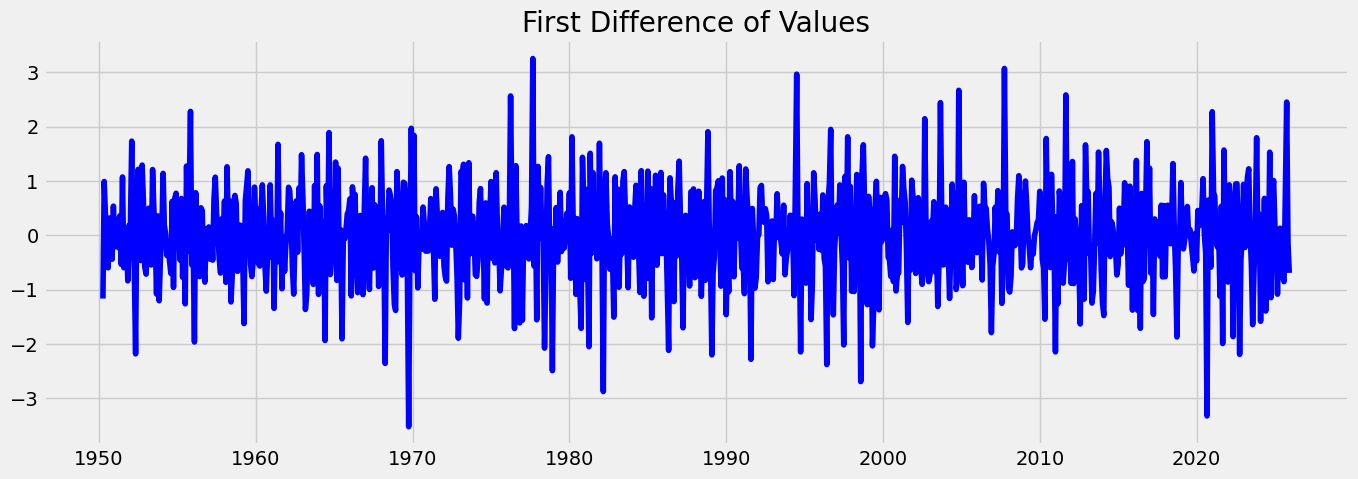

In [202]:
plt.figure(figsize=(15, 5))
plt.plot(first_diff , color='blue', label='first_diff')
plt.title('First Difference of Values')
plt.show()

- **constant mean**
- **constant variance**
- **constant autocorrelation**
- **I think it become stationary now**

## Try the tests again

In [203]:
adf_test = sm.tsa.adfuller(first_diff)
kpss_test = sm.tsa.kpss(first_diff)

C:\Users\ilchu\AppData\Local\Temp\ipykernel_20280\1517838418.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = sm.tsa.kpss(first_diff)


In [204]:
if adf_test[1] < 0.05 and kpss_test[1] > 0.05 :
    print('Stationary')
else:
    print('Non_Stationary')

Stationary


## ACF

<Figure size 1000x600 with 0 Axes>

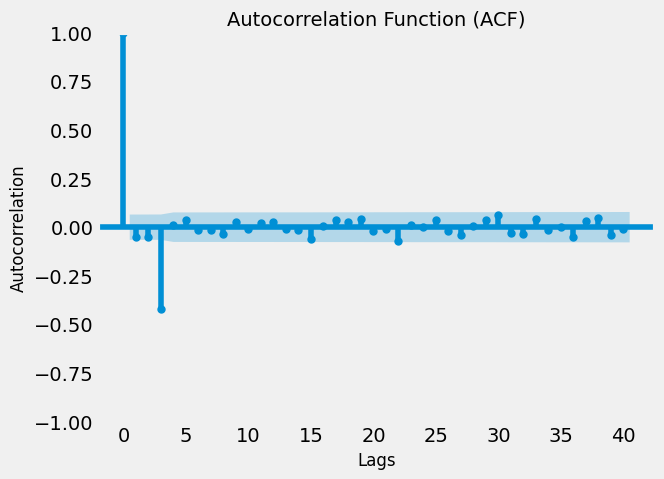

In [205]:
plt.figure(figsize=(10, 6))
plot_acf(first_diff, lags=40)
plt.title('Autocorrelation Function (ACF)', fontsize=14)
plt.xlabel('Lags', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.grid()
plt.show()

* **Based on the ACF, the sinusoidal pattern indicates seasonality, but the value of MA(0) is not clearly defined.**

## PACF

<Figure size 1000x600 with 0 Axes>

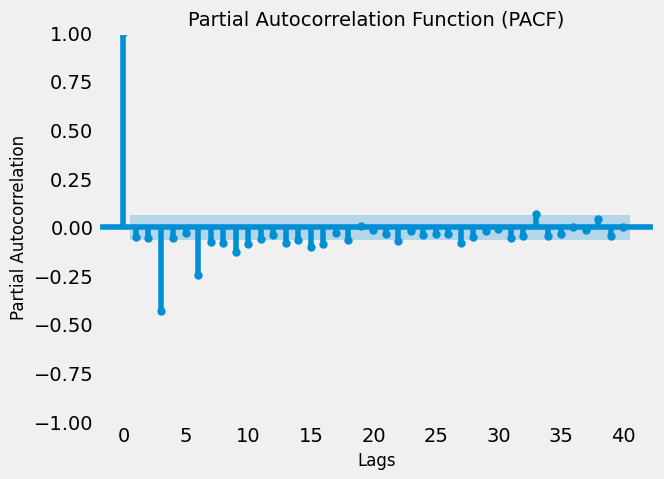

In [206]:
plt.figure(figsize=(10, 6))
plot_pacf(first_diff, lags=40)
plt.title('Partial Autocorrelation Function (PACF)', fontsize=14)
plt.xlabel('Lags', fontsize=12)
plt.ylabel('Partial Autocorrelation', fontsize=12)
plt.grid()
plt.show()

<a id="1"></a>
# <div style="text-align:center; border-radius:25px 70px; padding:9px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#FF7F50; overflow:hidden"><b>Modeling</b></div>

In [207]:
train_end = datetime(2010,12,1)
train_data = first_diff[:train_end]
test_data = first_diff[datetime(2011,1,1):]

## ARIMA

i:\NSTU\MOPAO\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
i:\NSTU\MOPAO\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
i:\NSTU\MOPAO\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  SPEI3   No. Observations:                  729
Model:                 ARIMA(4, 0, 0)   Log Likelihood                -830.406
Date:                Wed, 22 Apr 2026   AIC                           1672.812
Time:                        02:21:23   BIC                           1700.362
Sample:                    04-01-1950   HQIC                          1683.442
                         - 12-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0022      0.017      0.130      0.897      -0.031       0.036
ar.L1         -0.1031      0.042     -2.443      0.015      -0.186      -0.020
ar.L2         -0.1041      0.036     -2.912      0.0

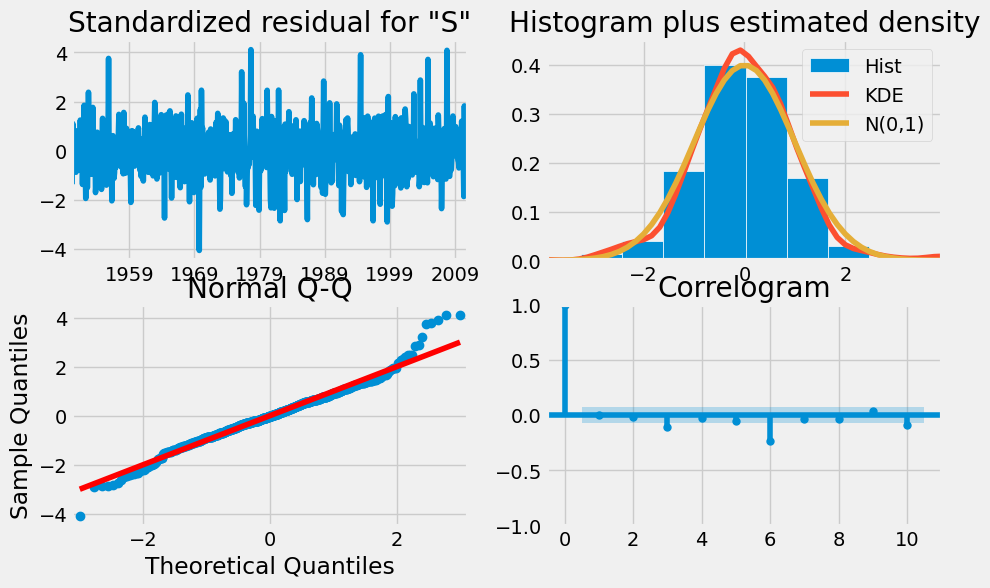

In [230]:
model = ARIMA(train_data, order=(4, 0, 0))


fitted_model = model.fit()

print(fitted_model.summary())


fitted_model.plot_diagnostics(figsize=(10, 6))
plt.show()

In [231]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]

In [232]:
predictions = fitted_model.predict(start=pred_start_date, end=pred_end_date)
residuals = test_data['SPEI3'] - predictions

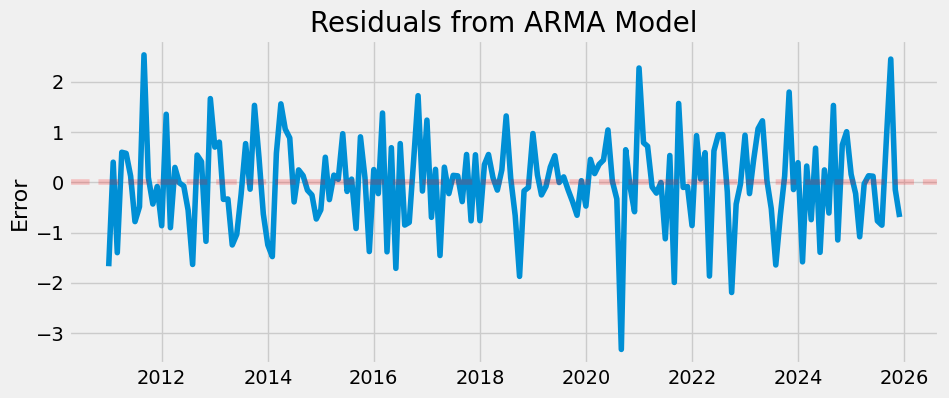

In [233]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title('Residuals from ARMA Model', fontsize=20)
plt.ylabel('Error', fontsize=16)
plt.axhline(0, color='r', linestyle='--', alpha=0.2)

Text(0, 0.5, 'Sales')

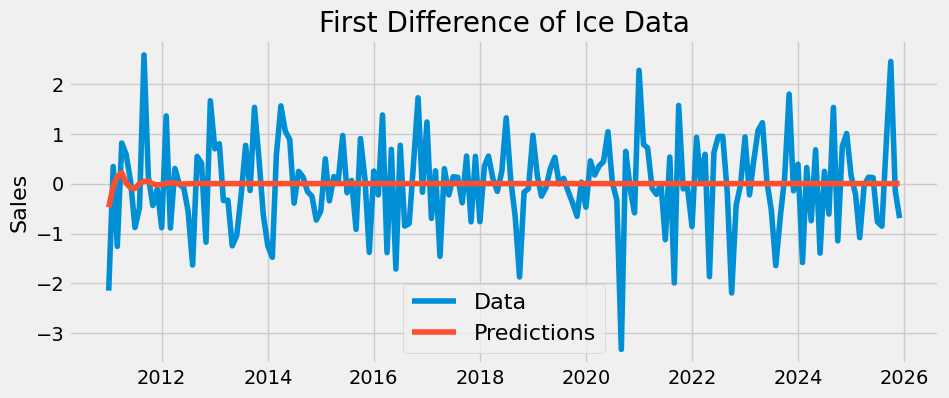

In [234]:
plt.figure(figsize=(10,4))

plt.plot(test_data)
plt.plot(predictions)

plt.legend(('Data', 'Predictions'), fontsize=16)

plt.title('First Difference of Ice Data', fontsize=20)
plt.ylabel('Sales', fontsize=16)

In [224]:
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals**2)))

Root Mean Squared Error: 0.9069109187118569


In [ ]:
from pmdarima import auto_arima

auto_arima_results = auto_arima(train_data, 
           start_p=0,
           start_q=0,
           max_p=52,
           max_q=52, # maximum p and q
           m=1,              # frequency of series
           d=None,           # let model determine 'd'
           seasonal=True,   # No Seasonality
           start_P=0, 
           D=0,  
           trace=True,
           error_action='ignore',  
           suppress_warnings=True, 
           stepwise=True)

auto_arima_results.summary()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1837.544, Time=0.34 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1838.222, Time=0.17 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1837.883, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1835.550, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.04 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 1.885 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  729
Model:                        SARIMAX   Log Likelihood                -916.775
Date:                Wed, 22 Apr 2026   AIC                           1835.550
Time:                        02:33:27   BIC                           1840.142
Sample:                    04-01-1950   HQIC                          1837.322
                         - 12-01-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.7242      0.030     24.034      0.000       0.665       0.783
===================================================================================
Ljung-Box (L1) (Q):                   1.32   Jarque-Bera (JB):                42.24
Prob(Q):                              0.25   Prob(JB):                         0.00
Heteroskedasticity (H):               1.09   Skew:                            -0.07
Prob(H) (two-sided):                  0.49   Kurtosis:                         4.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

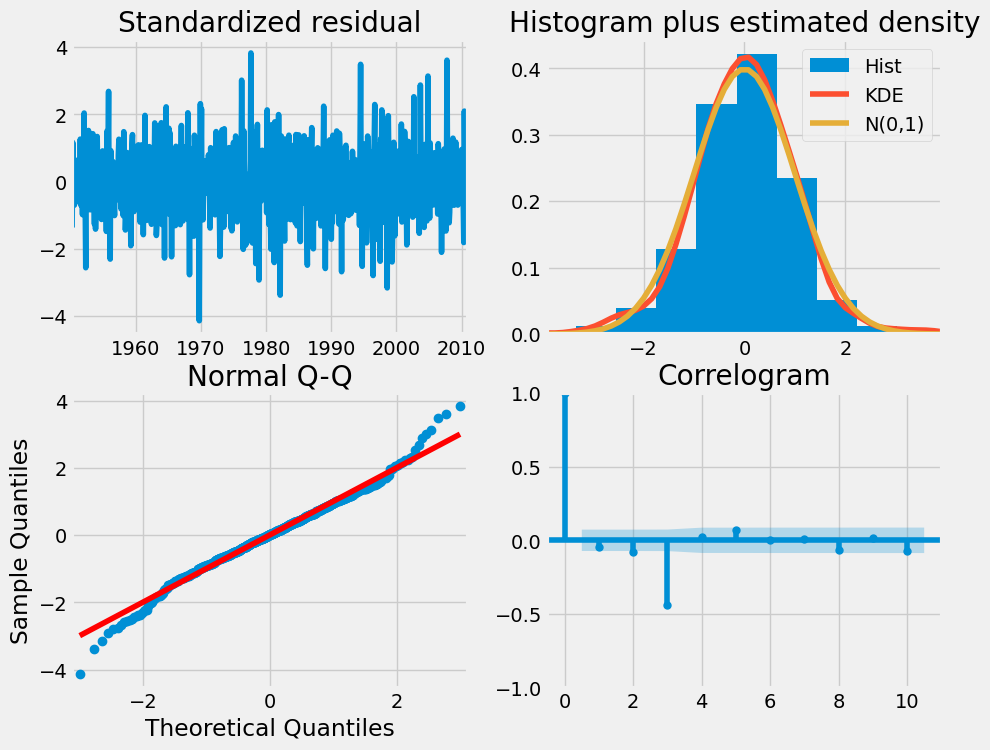

In [238]:
auto_arima_results.plot_diagnostics(figsize=(10,8))
plt.show()

In [247]:
predictions = auto_arima_results.predict(start=pred_start_date, end=pred_end_date)
residuals = test_data['SPEI3'] - predictions

In [249]:
rmse = np.sqrt(np.mean(residuals**2))
print('Root Mean Squared Error:', rmse)

Root Mean Squared Error: 0.9099841498550483


`this not bad but there's seasonality must carry about it.we will use SARIMA`

## Seasonality problem(SARIMA)

i:\NSTU\MOPAO\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
i:\NSTU\MOPAO\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                               SPEI3   No. Observations:                  729
Model:             SARIMAX(11, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -788.331
Date:                             Wed, 22 Apr 2026   AIC                           1602.663
Time:                                     00:21:38   BIC                           1662.355
Sample:                                 04-01-1950   HQIC                          1625.694
                                      - 12-01-2010                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1707      0.041     -4.169      0.000      -0.251      -0.090
ar.L2         -0.1886      

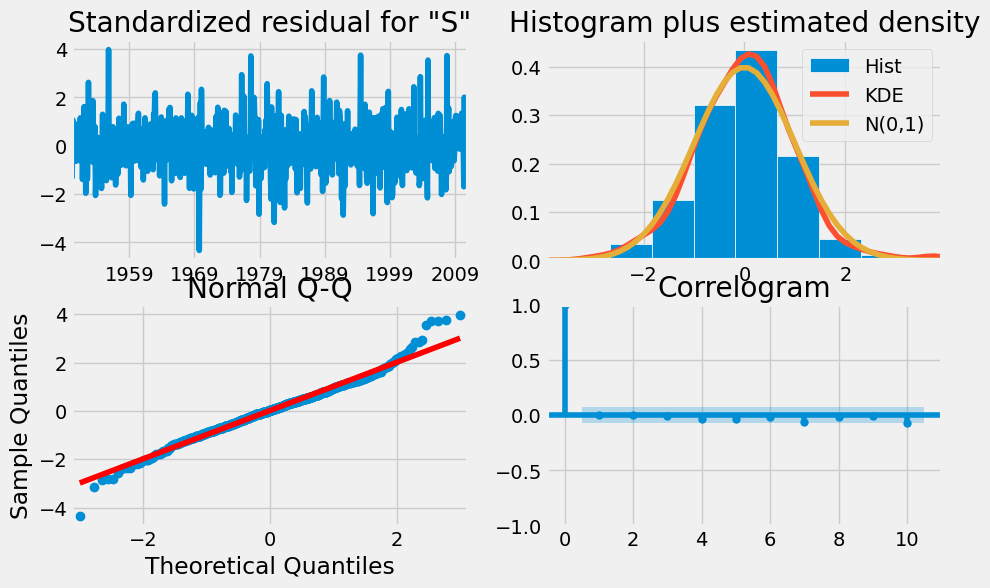

In [139]:
model = SARIMAX(train_data, 
                order=(11, 0, 0), 
                seasonal_order=(1, 0, 0, 12))

# Fit the model
fitted_model = model.fit()

# Print the summary of the fitted model
print(fitted_model.summary())

# Plot diagnostics
fitted_model.plot_diagnostics(figsize=(10, 6))
plt.show()

In [140]:
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]
#get the predictions and residuals
predictions = fitted_model.predict(start=pred_start_date, end=pred_end_date)
residuals = test_data['SPEI3'] - predictions

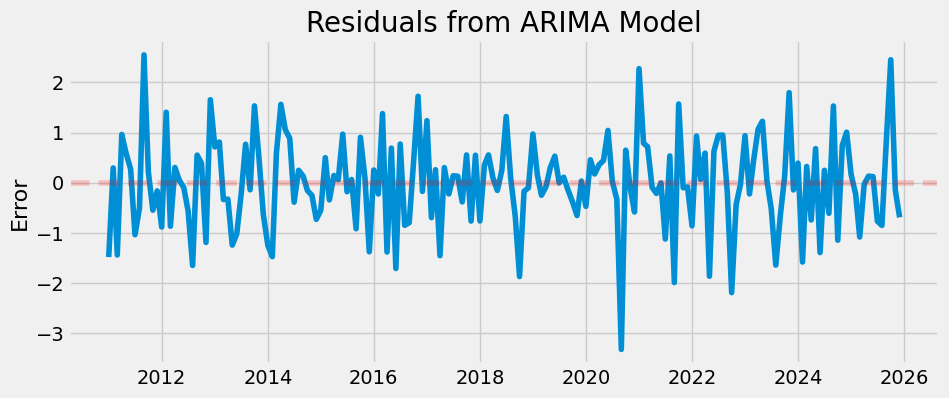

In [141]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title('Residuals from ARIMA Model', fontsize=20)
plt.ylabel('Error', fontsize=16)
plt.axhline(0, color='r', linestyle='--', alpha=0.2)

Text(0, 0.5, 'Sales')

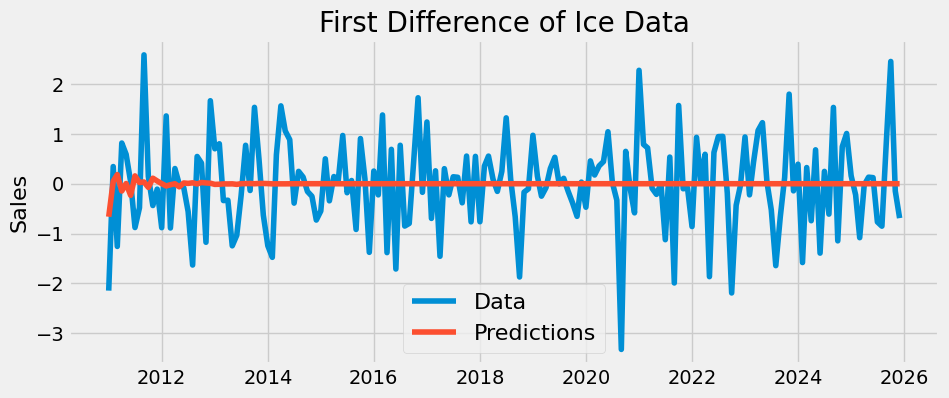

In [142]:
plt.figure(figsize=(10,4))
plt.plot(test_data)
plt.plot(predictions)
plt.legend(('Data', 'Predictions'), fontsize=16)
plt.title('First Difference of Ice Data', fontsize=20)
plt.ylabel('Sales', fontsize=16)

In [143]:
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals**2)))

Root Mean Squared Error: 0.9032407438114191


`this's better from above`

In [144]:
df_cop = df.copy()

## Feature Engineering

In [ ]:
import pandas as pd
import numpy as np


# --- Create Lag Features ---
lags = 12
for i in range(1, lags + 1):
    df_cop[f"Lag_{i}"] = df_cop["SPEI3"].shift(i)

# --- Rolling Statistics Features ---
rolling_windows = [3, 6, 12]
for window in rolling_windows:
    df_cop[f"Rolling_Mean_{window}"] = df_cop["SPEI3"].rolling(window=window).mean()
    df_cop[f"Rolling_Std_{window}"] = df_cop["SPEI3"].rolling(window=window).std()
    df_cop[f"Rolling_Min_{window}"] = df_cop["SPEI3"].rolling(window=window).min()
    df_cop[f"Rolling_Max_{window}"] = df_cop["SPEI3"].rolling(window=window).max()



# --- Exponential Weighted Moving Averages ---
df_cop['EWMA_12'] = df_cop["SPEI3"].ewm(span=12).mean()
df_cop['EWMA_6'] = df_cop["SPEI3"].ewm(span=6).mean()

# --- Differencing Features ---
df_cop['Diff_1'] = df_cop["SPEI3"].diff(1)
df_cop['Diff_12'] = df_cop["SPEI3"].diff(12) 


df_cop = df_cop.dropna()


X = df_cop.drop(columns=["SPEI3"])
y = df_cop["SPEI3"]


print(f"Shape of feature set: {X.shape}")
print(f"Shape of target variable: {y.shape}")


Shape of feature set: (874, 28)
Shape of target variable: (874,)


In [240]:
train_end = datetime(2010,12,1)
train_data = df_cop[:train_end]
test_data = df_cop[datetime(2011,1,1):]

In [241]:
X_train=train_data.drop('SPEI3',axis=1)
y_train=train_data['SPEI3']

X_test=test_data.drop('SPEI3',axis=1)
y_test=test_data['SPEI3']

## Xgboost

In [242]:
model = XGBRegressor(learning_rate=0.05, n_estimators=200, max_depth=5)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [243]:
model.score(X_train,y_train)

0.9993816632070572

In [244]:
model.score(X_test,y_test)

0.9626891645941363

`That's an awesome score`

Mean Squared Error: 0.03764039537998493
Root Mean Squared Error: 0.1940113279682012


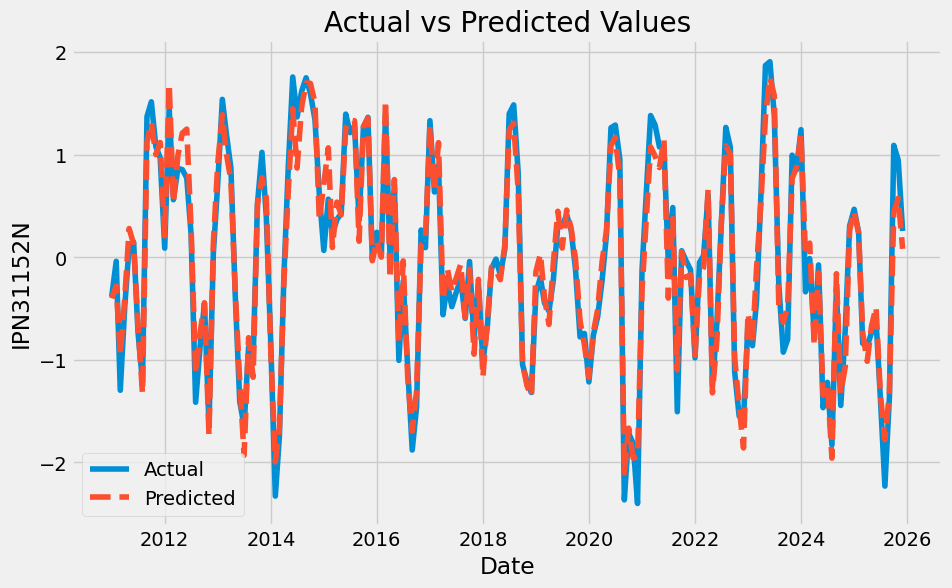

In [245]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted", linestyle="--")
plt.legend()
plt.title("Actual vs Predicted Values")
plt.xlabel("Date")
plt.ylabel("IPN31152N")
plt.show()


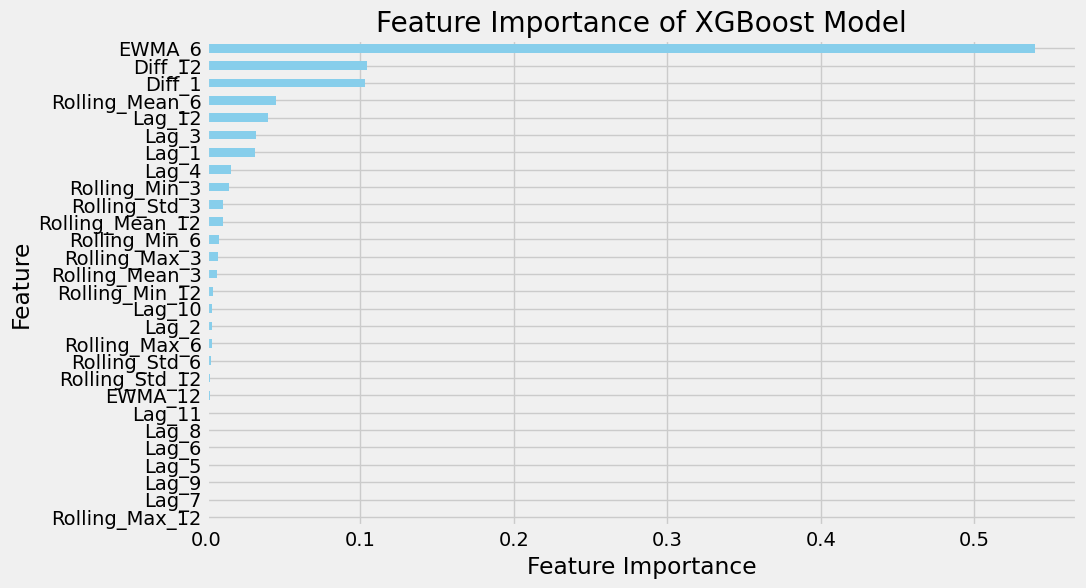

In [246]:
importance = model.feature_importances_


importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance}).sort_values(by="Importance", ascending=False)

# Plot the feature importance
importance_df.plot(kind='barh', x='Feature', y='Importance', color='skyblue', figsize=(10, 6), legend=False)
plt.xlabel("Feature Importance")
plt.title("Feature Importance of XGBoost Model")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

`XGBoost is the best thing so far.`

## Try RNN -> LSTMs

In [157]:
train_end = datetime(2010,12,1)
train_data = df[:train_end]
test_data = df[datetime(2011,1,1):]

In [158]:
scaler = MinMaxScaler()
scaled_train_data = scaler.fit_transform(train_data.values.reshape(-1, 1))

In [159]:
def create_dataset(data, time_step=12):
    x, y = [], []
    for i in range(time_step, len(data)):
        x.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

In [160]:
time_step = 12
X_train, y_train = create_dataset(scaled_train_data, time_step)

In [161]:
scaled_test_data = scaler.transform(test_data.values.reshape(-1, 1))

In [162]:
X_test, y_test = create_dataset(scaled_test_data, time_step)

In [163]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

## LSTM model

In [179]:
# Build the LSTM model
model = Sequential()


model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=1))  

model.compile(optimizer='adam', loss='mean_squared_error')

i:\NSTU\MOPAO\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [180]:

history = model.fit(X_train, y_train, epochs=400, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0828 - val_loss: 0.0364
Epoch 2/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0337 - val_loss: 0.0351
Epoch 3/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0330 - val_loss: 0.0357
Epoch 4/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0331 - val_loss: 0.0358
Epoch 5/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0330 - val_loss: 0.0357
Epoch 6/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0327 - val_loss: 0.0356
Epoch 7/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0325 - val_loss: 0.0353
Epoch 8/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0322 - val_loss: 0.0351
Epoch 9/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0320 - val_loss: 0.0348
Epoch 10/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0318 - val_loss: 0.0345
Epoch 11/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0316 - val_loss: 0.0342
Epoch 12/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

In [181]:
# Predict the test set results
y_pred = model.predict(X_test)

# Inverse the scaling to get the actual predicted values
y_pred_actual = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate Mean Squared Error
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
Mean Squared Error: 0.880964010862634
Root Mean Squared Error: 0.9385968308398628


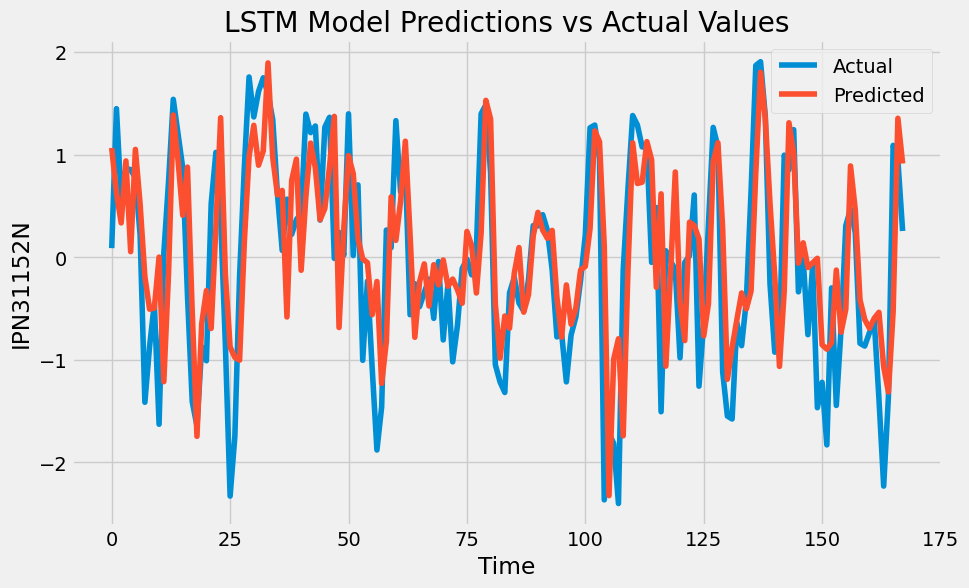

In [178]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred_actual, label="Predicted")
plt.title("LSTM Model Predictions vs Actual Values")
plt.xlabel("Time")
plt.ylabel("IPN31152N")
plt.legend()
plt.show()